# Домашнее задание к семинарам 10-11 (HW10-11)

Тема: компьютерное зрение в PyTorch.  
Часть S10: CNN, аугментации, transfer learning на ResNet.  
Часть S11: детекция или сегментация, корректная визуализация и базовая валидация.

HW10-11 выполняется в личном репозитории студента (на основе шаблона курса) в папке `homeworks/HW10-11/`.

## 2.4.1. Импорты, seed и устройство

1. Импортировать библиотеки: `torch`, `torchvision`, `numpy`, `matplotlib` (и всё, что нужно по делу).
2. Зафиксировать seed (минимум `torch.manual_seed`, желательно также `numpy`).
3. Определить устройство (`cuda` при наличии, иначе `cpu`) и убедиться, что и модель, и батчи переводятся на один device.

In [1]:
import os
import json
import csv
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision import datasets, models
import torchvision.transforms as transforms
from torchvision.datasets import STL10

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

MEAN_A = [0.485, 0.456, 0.406]
STD_A  = [0.229, 0.224, 0.225]

DATA_DIR      = './data'
ARTIFACTS_DIR = './artifacts'
FIGURES_DIR   = './artifacts/figures'

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR,   exist_ok=True)

Device: cpu


## 2.4.2. Данные и DataLoader

### Часть A — STL10

1. Загрузить выбранный классификационный датасет для части A.
2. Подготовить transforms для части A:
   - базовый transform для CNN;
   - transform с аугментациями;
   - preprocessing для ResNet с pretrained weights.
3. Создать `DataLoader` для train/val/test в части A.
5. Показать sanity-check и примеры изображений для части A.

In [2]:
IMG_SIZE = 96

# Базовый transform для CNN
transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_A, std=STD_A),
])

# Transform с аугментациями
transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_A, std=STD_A),
])

# Preprocessing для ResNet с pretrained weights
transform_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_A, std=STD_A),
])

In [4]:
# Загружаем датасет с transform_base для C1/C2
full_train_base = STL10(root='./data', split='train', download=True, transform=transform_base)
full_test_base  = STL10(root='./data', split='test',  download=True, transform=transform_base)

# Воспроизводимое разделение train/val (80/20) с фиксированным seed
generator = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(full_train_base), generator=generator).tolist()
n_train = int(len(full_train_base) * 0.8)
train_indices = perm[:n_train]
val_indices   = perm[n_train:]

train_ds_A = Subset(full_train_base, train_indices)
val_ds_A   = Subset(full_train_base, val_indices)

# DataLoader для C1/C2 (base transform, 96x96)
train_loader = DataLoader(train_ds_A,   batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds_A,     batch_size=32, shuffle=False)
test_loader  = DataLoader(full_test_base, batch_size=32, shuffle=False)

# Отдельные загрузчики для C3/C4 (transform_resnet, 224x224)
full_train_rn    = STL10(root='./data', split='train', download=False, transform=transform_resnet)
full_test_rn     = STL10(root='./data', split='test',  download=False, transform=transform_resnet)
full_train_aug_ds = STL10(root='./data', split='train', download=False, transform=transform_aug)

train_ds_rn  = Subset(full_train_rn,    train_indices)
val_ds_rn    = Subset(full_train_rn,    val_indices)
train_ds_aug = Subset(full_train_aug_ds, train_indices)

train_loader_rn  = DataLoader(train_ds_rn,  batch_size=32, shuffle=True)
val_loader_rn    = DataLoader(val_ds_rn,    batch_size=32, shuffle=False)
test_loader_rn   = DataLoader(full_test_rn, batch_size=32, shuffle=False)
train_loader_aug = DataLoader(train_ds_aug, batch_size=32, shuffle=True)

classes = full_train_base.classes
print(f'Train samples : {len(train_ds_A)}')
print(f'Val   samples : {len(val_ds_A)}')
print(f'Test  samples : {len(full_test_base)}')

x_batch, y_batch = next(iter(train_loader))
print(f'\nБатч x.shape : {x_batch.shape}')
print(f'Батч y.shape : {y_batch.shape}')
print(f'Batch size   : {x_batch.shape[0]}')
print(f'\nКлассы ({len(classes)}): {classes}')

100%|██████████| 2.64G/2.64G [51:23<00:00, 856kB/s]    


Train samples : 4000
Val   samples : 1000
Test  samples : 8000

Батч x.shape : torch.Size([32, 3, 96, 96])
Батч y.shape : torch.Size([32])
Batch size   : 32

Классы (10): ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


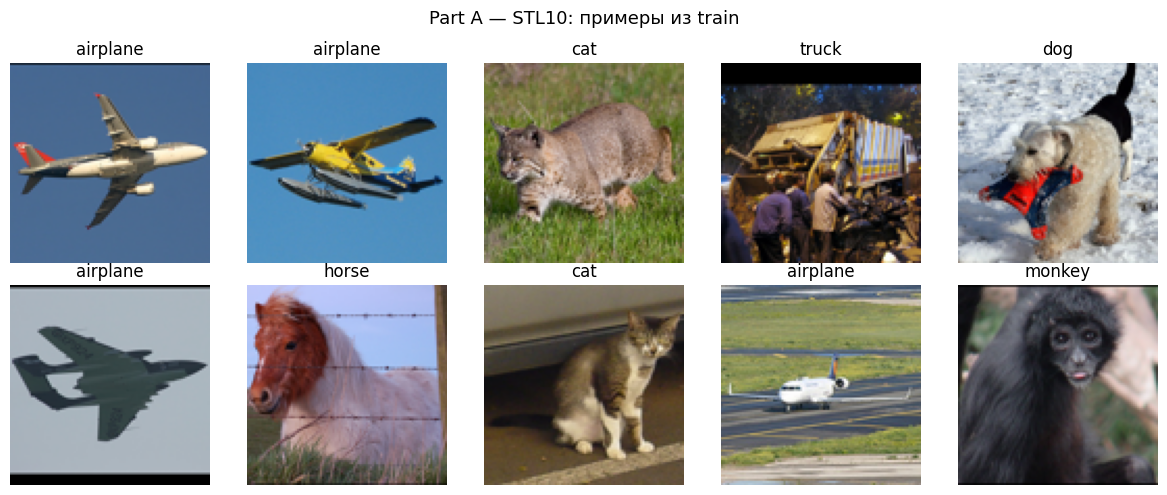

In [5]:
# Вспомогательная функция денормализации
def denormalize(tensor, mean, std):
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

# Sanity-check: примеры изображений части A
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Part A — STL10: примеры из train', fontsize=13)
axes = axes.flatten()
for i in range(10):
    img, label = train_ds_A[i]
    axes[i].imshow(denormalize(img, MEAN_A, STD_A).permute(1, 2, 0).numpy())
    axes[i].set_title(classes[label])
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/sanity_check_A.png', dpi=120, bbox_inches='tight')
plt.show()

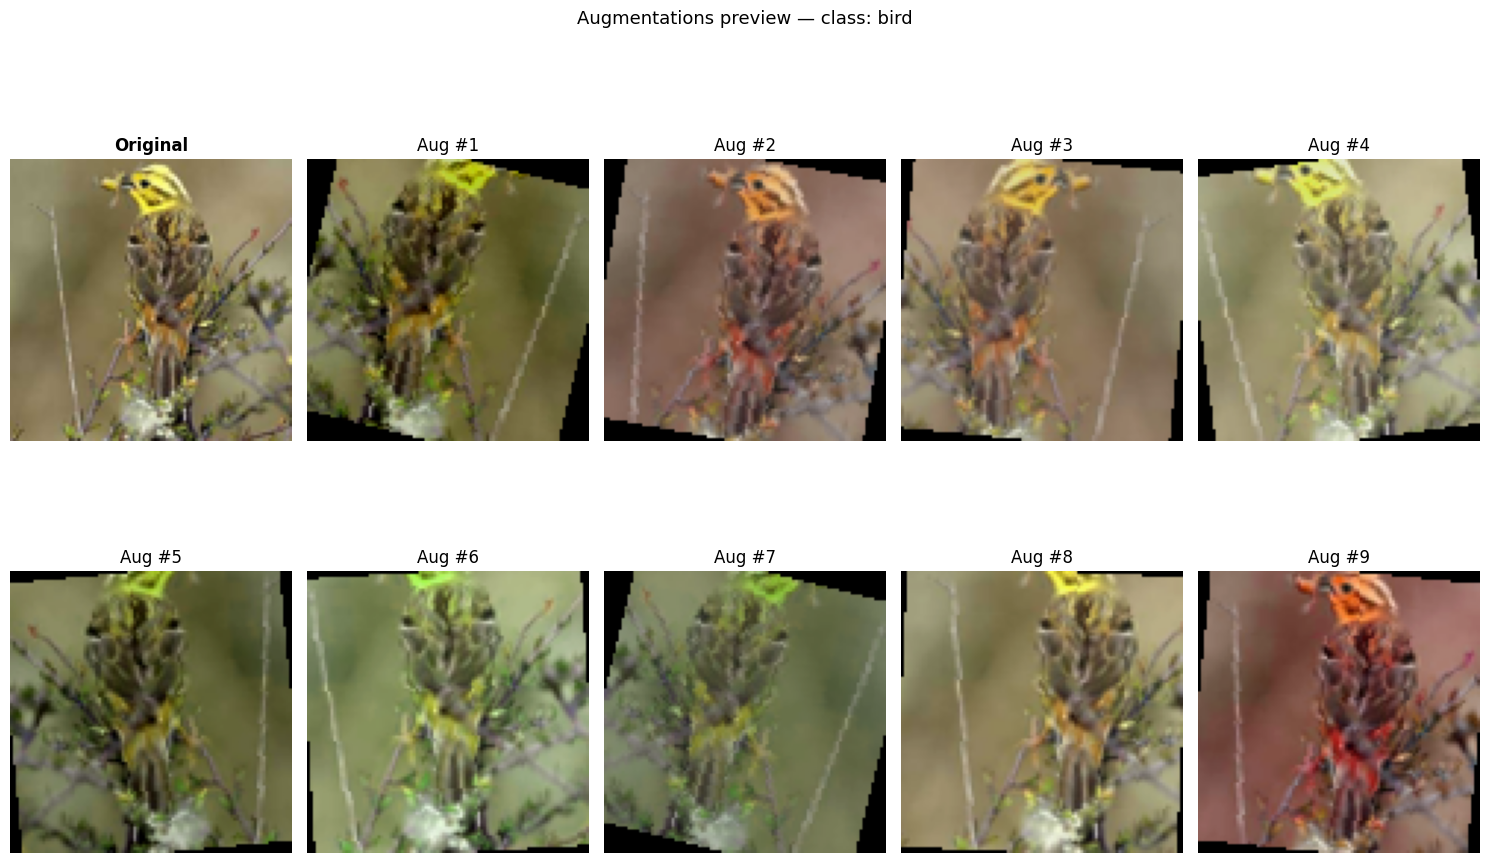

Сохранено: artifacts/figures/augmentations_preview.png


In [7]:
# Визуализация аугментаций для части A (augmentations_preview.png)
# Одно исходное изображение + 9 аугментированных версий
raw_ds = STL10(root='./data', split='train', download=False,
               transform=transforms.ToTensor())
orig_img_tensor, orig_label = raw_ds[0]
orig_img_pil = transforms.ToPILImage()(orig_img_tensor)

aug_only = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
])

fig, axes = plt.subplots(2, 5, figsize=(15, 10))
axes = axes.flatten()
axes[0].imshow(orig_img_tensor.permute(1, 2, 0).numpy())
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')
for i in range(1, 10):
    aug_img = aug_only(orig_img_pil)
    axes[i].imshow(aug_img.permute(1, 2, 0).numpy())
    axes[i].set_title(f'Aug #{i}')
    axes[i].axis('off')
plt.suptitle(f'Augmentations preview — class: {classes[orig_label]}', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/augmentations_preview.png', dpi=120, bbox_inches='tight')
plt.show()
print('Сохранено: artifacts/figures/augmentations_preview.png')

### Часть B — OxfordIIITPet (Segmentation)

4. Загрузить выбранный датасет для части B.
5. Показать sanity-check и примеры изображений для части B.

In [8]:
from torchvision.datasets import OxfordIIITPet

target_transform_B = transforms.Compose([
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
])

img_transform_B = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_A, std=STD_A),
])

train_ds_B = OxfordIIITPet(
    root='./data_B', split='trainval',
    target_types='segmentation',
    transform=img_transform_B,
    target_transform=target_transform_B,
    download=True,
)

test_ds_B = OxfordIIITPet(
    root='./data_B', split='test',
    target_types='segmentation',
    transform=img_transform_B,
    target_transform=target_transform_B,
    download=True,
)

train_loader_B = DataLoader(train_ds_B, batch_size=16, shuffle=True,  num_workers=2)
test_loader_B  = DataLoader(test_ds_B,  batch_size=16, shuffle=False, num_workers=2)

imgs_B, masks_B = next(iter(train_loader_B))
print(f'images : {imgs_B.shape}   dtype={imgs_B.dtype}')
print(f'masks  : {masks_B.shape}   dtype={masks_B.dtype}')
print(f'unique mask values: {masks_B.unique().tolist()}')

100%|██████████| 792M/792M [06:27<00:00, 2.04MB/s] 
100%|██████████| 19.2M/19.2M [00:07<00:00, 2.40MB/s]


images : torch.Size([16, 3, 128, 128])   dtype=torch.float32
masks  : torch.Size([16, 1, 128, 128])   dtype=torch.uint8
unique mask values: [1, 2, 3]


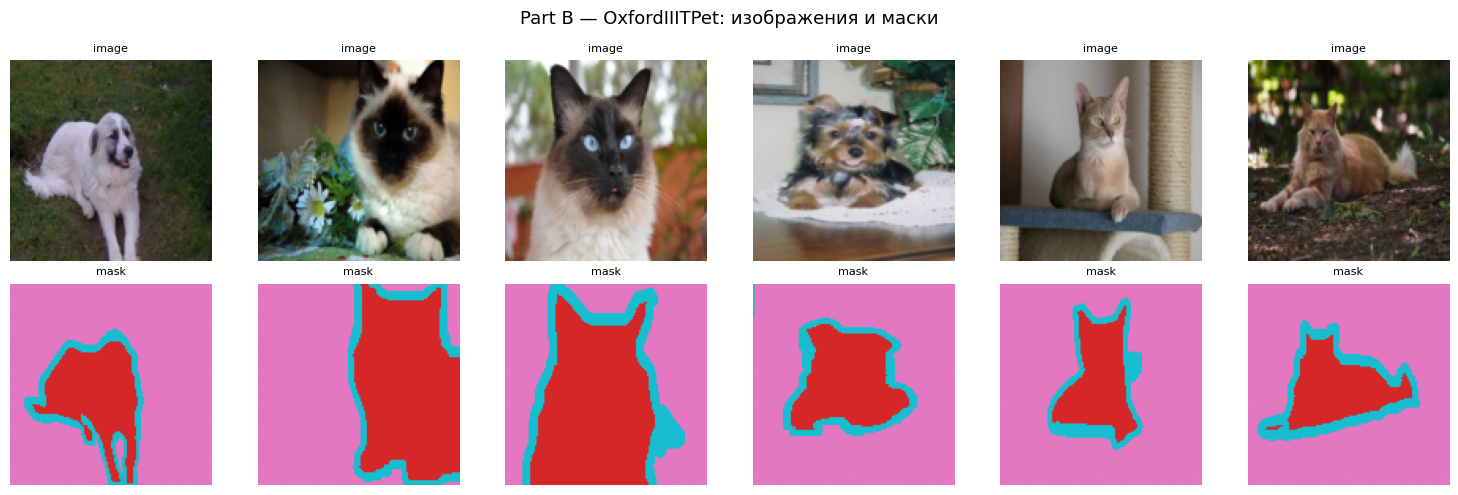

In [9]:
# Sanity-check: примеры изображений и масок части B
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Part B — OxfordIIITPet: изображения и маски', fontsize=13)
for i in range(6):
    img  = denormalize(imgs_B[i], MEAN_A, STD_A).permute(1, 2, 0).numpy()
    mask = masks_B[i].squeeze().numpy()
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title('image', fontsize=8)
    axes[1, i].imshow(mask, cmap='tab10', vmin=0, vmax=3)
    axes[1, i].axis('off')
    axes[1, i].set_title('mask', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/sanity_check_B.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.4.3. Базовые функции обучения и оценки

Для части A реализовать и использовать:
- `train_one_epoch(...)`
- `evaluate(...)`
- логирование истории обучения: train/val loss и train/val accuracy по эпохам

Для части B реализовать:
- визуализацию предсказаний модели на нескольких примерах;
- расчёт базовых метрик под выбранный трек;
- краткую табличную фиксацию результатов в `runs.csv`.

In [10]:
# --- Функции для части A ---

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            total_loss += criterion(out, labels).item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


def plot_history(history, title='', save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='train')
    ax1.plot(history['val_loss'],   label='val')
    ax1.set_title(f'Loss — {title}'); ax1.legend(); ax1.grid(True)
    ax2.plot(history['train_acc'], label='train')
    ax2.plot(history['val_acc'],   label='val')
    ax2.set_title(f'Accuracy — {title}'); ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()



RUNS_CSV = f'{ARTIFACTS_DIR}/runs.csv'
FIELDNAMES = [
    'experiment_id', 'task', 'dataset', 'seed', 'model_summary',
    'optimizer', 'lr', 'epochs_trained',
    'best_val_accuracy', 'test_accuracy',
    'precision', 'recall', 'mean_iou', 'notes'
]

def log_run(experiment_id, task, dataset, model_summary, optimizer_name,
            lr, epochs_trained, best_val_accuracy='', test_accuracy='',
            precision='', recall='', mean_iou='', notes=''):
    row = {
        'experiment_id':    experiment_id,
        'task':             task,
        'dataset':          dataset,
        'seed':             SEED,
        'model_summary':    model_summary,
        'optimizer':        optimizer_name,
        'lr':               lr,
        'epochs_trained':   epochs_trained,
        'best_val_accuracy': best_val_accuracy,
        'test_accuracy':    test_accuracy,
        'precision':        precision,
        'recall':           recall,
        'mean_iou':         mean_iou,
        'notes':            notes,
    }
    file_exists = os.path.isfile(RUNS_CSV)
    with open(RUNS_CSV, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)
    print(f'Logged: {experiment_id}')



def predict_mask(model, img_tensor, device):
    with torch.no_grad():
        out = model(img_tensor.unsqueeze(0).to(device))['out'] 
    return out.squeeze(0) 


def seg_metrics_binary(pred_mask, gt_mask):
    gt = (gt_mask.squeeze() == 1).long()
    pr = pred_mask.long()
    intersection = (pr & gt).sum().item()
    union        = (pr | gt).sum().item()
    iou          = intersection / (union + 1e-6)
    precision    = intersection / (pr.sum().item() + 1e-6)
    recall       = intersection / (gt.sum().item() + 1e-6)
    return iou, precision, recall


def evaluate_seg(model, loader, postprocess_fn, device, n_batches=10):
    ious, precs, recs = [], [], []
    for i, (imgs, masks) in enumerate(loader):
        if i >= n_batches:
            break
        for j in range(len(imgs)):
            logits        = predict_mask(model, imgs[j], device)
            pred          = postprocess_fn(logits)
            iou, p, r     = seg_metrics_binary(pred, masks[j].cpu())
            ious.append(iou); precs.append(p); recs.append(r)
    mean_iou  = np.mean(ious)
    mean_prec = np.mean(precs)
    mean_rec  = np.mean(recs)
    print(f'mean_iou        : {mean_iou:.4f}')
    print(f'pixel_precision : {mean_prec:.4f}')
    print(f'pixel_recall    : {mean_rec:.4f}')
    return mean_iou, mean_prec, mean_rec

## 3. Эксперименты

В домашней работе есть две части: (A) классификация изображений (S10) и (B) structured vision (S11).  
Все результаты прогонов фиксируются в `artifacts/runs.csv`.

### 3.1. Часть A (S10): классификация, аугментации и transfer learning

Задача: показать эффект CNN, аугментаций и transfer learning.

Провести 4 эксперимента (C1–C4):
- **C1 (simple-cnn-base)**: простая CNN без аугментаций.
- **C2 (simple-cnn-aug)**: та же CNN, но с разумными аугментациями.
- **C3 (resnet18-head-only)**: `ResNet18` с pretrained weights; backbone заморожен, обучается только классификационная голова.
- **C4 (resnet18-finetune)**: `ResNet18` с pretrained weights; частичное fine-tune (`layer4 + fc`).

Требования: loss — `CrossEntropyLoss`; основная метрика — accuracy; фиксированный split, фиксированный seed.

[C1] Epoch  1/10 | loss 1.8084/1.4578 | acc 0.318/0.443
[C1] Epoch  2/10 | loss 1.3576/1.3139 | acc 0.494/0.512
[C1] Epoch  3/10 | loss 1.1278/1.3453 | acc 0.590/0.506
[C1] Epoch  4/10 | loss 0.9000/1.2942 | acc 0.672/0.548
[C1] Epoch  5/10 | loss 0.6747/1.2690 | acc 0.762/0.560
[C1] Epoch  6/10 | loss 0.4574/1.5696 | acc 0.840/0.579
[C1] Epoch  7/10 | loss 0.3159/1.7488 | acc 0.883/0.548
[C1] Epoch  8/10 | loss 0.2128/1.7519 | acc 0.926/0.565
[C1] Epoch  9/10 | loss 0.1640/1.9365 | acc 0.943/0.569
[C1] Epoch 10/10 | loss 0.1208/2.0834 | acc 0.962/0.580


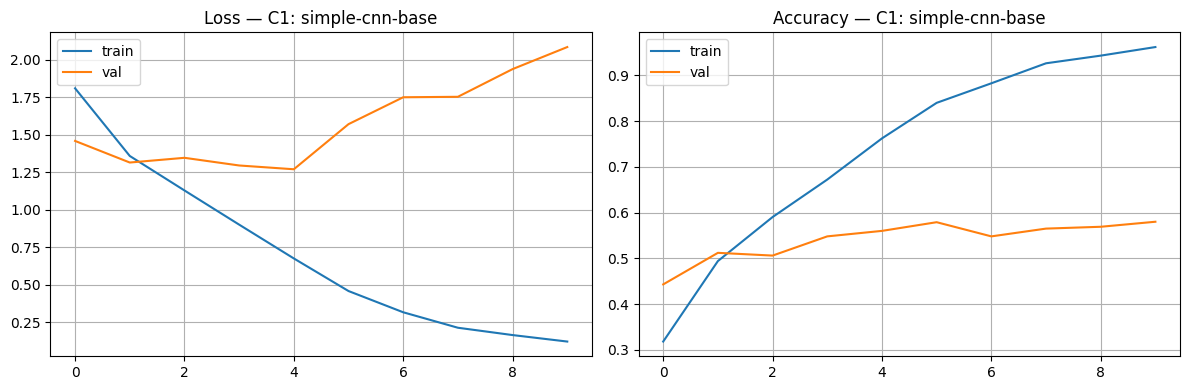

Logged: C1


In [11]:
# C1: simple-cnn-base — простая CNN без аугментаций

criterion = nn.CrossEntropyLoss()

model_c1 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128 * 12 * 12, 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, 10),
).to(DEVICE)

optimizer_c1 = torch.optim.Adam(model_c1.parameters(), lr=1e-3)

history_c1 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(1, 11):
    tr_loss, tr_acc = train_one_epoch(model_c1, train_loader, criterion, optimizer_c1, DEVICE)
    vl_loss, vl_acc = evaluate(model_c1, val_loader, criterion, DEVICE)
    history_c1['train_loss'].append(tr_loss); history_c1['val_loss'].append(vl_loss)
    history_c1['train_acc'].append(tr_acc);  history_c1['val_acc'].append(vl_acc)
    print(f'[C1] Epoch {epoch:>2}/10 | loss {tr_loss:.4f}/{vl_loss:.4f} | acc {tr_acc:.3f}/{vl_acc:.3f}')

plot_history(history_c1, title='C1: simple-cnn-base',
             save_path=f'{FIGURES_DIR}/curves_C1.png')
log_run('C1', 'classification', 'STL10',
        'SimpleCNN-3conv', 'Adam', 1e-3, 10,
        best_val_accuracy=round(max(history_c1['val_acc']), 4),
        notes='no augmentations')

[C2] Epoch  1/10 | loss 2.0891/1.7803 | acc 0.217/0.321
[C2] Epoch  2/10 | loss 1.7646/1.6322 | acc 0.330/0.384
[C2] Epoch  3/10 | loss 1.6441/1.5052 | acc 0.367/0.437
[C2] Epoch  4/10 | loss 1.5725/1.4240 | acc 0.404/0.480
[C2] Epoch  5/10 | loss 1.5038/1.3721 | acc 0.433/0.494
[C2] Epoch  6/10 | loss 1.4506/1.4198 | acc 0.457/0.466
[C2] Epoch  7/10 | loss 1.4120/1.4404 | acc 0.464/0.474
[C2] Epoch  8/10 | loss 1.3782/1.2893 | acc 0.494/0.520
[C2] Epoch  9/10 | loss 1.3273/1.2645 | acc 0.519/0.532
[C2] Epoch 10/10 | loss 1.3161/1.2676 | acc 0.514/0.534


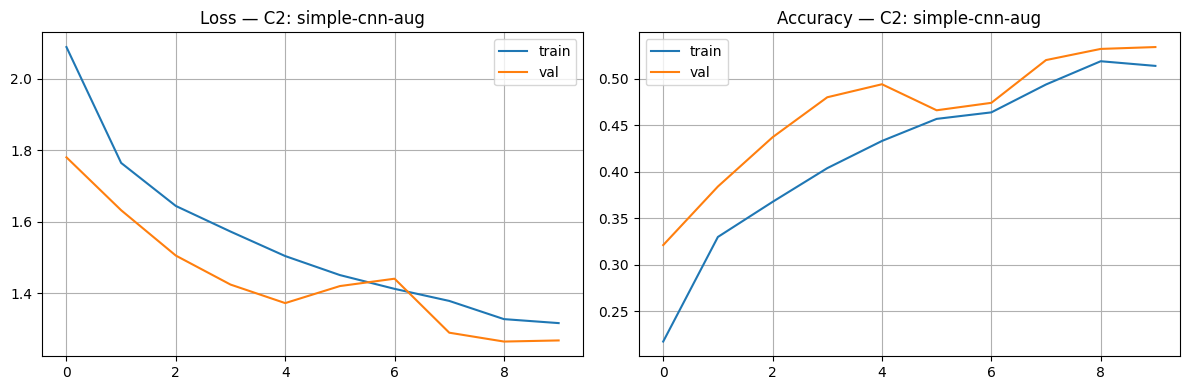

Logged: C2


In [12]:
# C2: simple-cnn-aug — та же CNN, но с разумными аугментациями

model_c2 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128 * 12 * 12, 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, 10),
).to(DEVICE)

optimizer_c2 = torch.optim.Adam(model_c2.parameters(), lr=1e-3)

history_c2 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(1, 11):
    tr_loss, tr_acc = train_one_epoch(model_c2, train_loader_aug, criterion, optimizer_c2, DEVICE)
    vl_loss, vl_acc = evaluate(model_c2, val_loader, criterion, DEVICE)
    history_c2['train_loss'].append(tr_loss); history_c2['val_loss'].append(vl_loss)
    history_c2['train_acc'].append(tr_acc);  history_c2['val_acc'].append(vl_acc)
    print(f'[C2] Epoch {epoch:>2}/10 | loss {tr_loss:.4f}/{vl_loss:.4f} | acc {tr_acc:.3f}/{vl_acc:.3f}')

plot_history(history_c2, title='C2: simple-cnn-aug',
             save_path=f'{FIGURES_DIR}/curves_C2.png')
log_run('C2', 'classification', 'STL10',
        'SimpleCNN-3conv', 'Adam', 1e-3, 10,
        best_val_accuracy=round(max(history_c2['val_acc']), 4),
        notes='with augmentations: RandomCrop, HFlip, ColorJitter, Rotation')

[C3] Epoch  1/10 | loss 0.8435/0.3660 | acc 0.790/0.918
[C3] Epoch  2/10 | loss 0.3157/0.2578 | acc 0.919/0.936
[C3] Epoch  3/10 | loss 0.2403/0.2310 | acc 0.932/0.932
[C3] Epoch  4/10 | loss 0.2141/0.2273 | acc 0.940/0.933
[C3] Epoch  5/10 | loss 0.1921/0.2146 | acc 0.943/0.930
[C3] Epoch  6/10 | loss 0.1674/0.1998 | acc 0.953/0.934
[C3] Epoch  7/10 | loss 0.1568/0.2090 | acc 0.954/0.938
[C3] Epoch  8/10 | loss 0.1457/0.1947 | acc 0.956/0.938
[C3] Epoch  9/10 | loss 0.1344/0.1871 | acc 0.960/0.936
[C3] Epoch 10/10 | loss 0.1325/0.1929 | acc 0.960/0.941


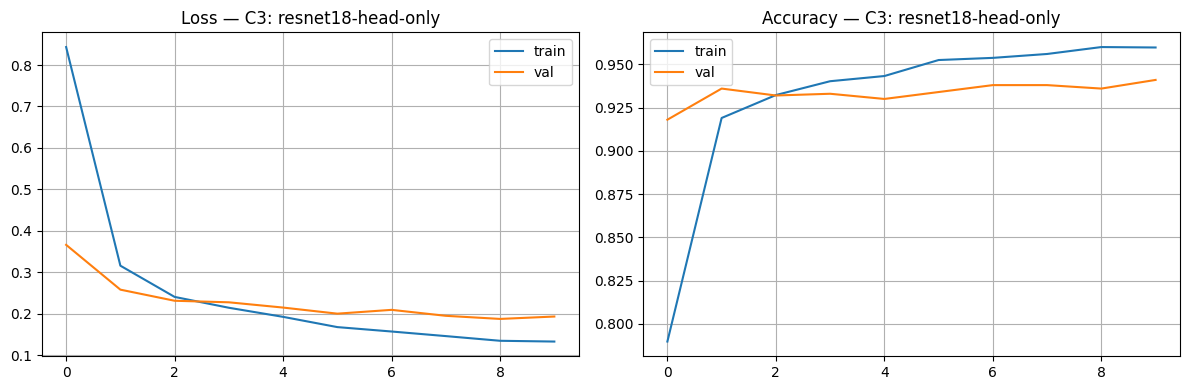

Logged: C3


In [13]:
# C3: resnet18-head-only — ResNet18 с pretrained weights; backbone заморожен,
# обучается только классификационная голова

model_c3 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in model_c3.parameters():
    p.requires_grad = False
model_c3.fc = nn.Linear(model_c3.fc.in_features, 10)
model_c3 = model_c3.to(DEVICE)

optimizer_c3 = torch.optim.Adam(model_c3.fc.parameters(), lr=1e-3)

history_c3 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(1, 11):
    tr_loss, tr_acc = train_one_epoch(model_c3, train_loader_rn, criterion, optimizer_c3, DEVICE)
    vl_loss, vl_acc = evaluate(model_c3, val_loader_rn, criterion, DEVICE)
    history_c3['train_loss'].append(tr_loss); history_c3['val_loss'].append(vl_loss)
    history_c3['train_acc'].append(tr_acc);  history_c3['val_acc'].append(vl_acc)
    print(f'[C3] Epoch {epoch:>2}/10 | loss {tr_loss:.4f}/{vl_loss:.4f} | acc {tr_acc:.3f}/{vl_acc:.3f}')

plot_history(history_c3, title='C3: resnet18-head-only',
             save_path=f'{FIGURES_DIR}/curves_C3.png')
log_run('C3', 'classification', 'STL10',
        'ResNet18-head-only', 'Adam', 1e-3, 10,
        best_val_accuracy=round(max(history_c3['val_acc']), 4),
        notes='pretrained ResNet18, backbone frozen, only fc trained')

[C4] Epoch  1/10 | loss 0.4732/0.3573 | acc 0.845/0.879
[C4] Epoch  2/10 | loss 0.1522/0.3056 | acc 0.952/0.903
[C4] Epoch  3/10 | loss 0.0754/0.3769 | acc 0.976/0.889
[C4] Epoch  4/10 | loss 0.0839/0.3978 | acc 0.972/0.889
[C4] Epoch  5/10 | loss 0.0618/0.3964 | acc 0.979/0.898
[C4] Epoch  6/10 | loss 0.0621/0.3589 | acc 0.979/0.904
[C4] Epoch  7/10 | loss 0.0667/0.4410 | acc 0.977/0.882
[C4] Epoch  8/10 | loss 0.0404/0.3902 | acc 0.986/0.899
[C4] Epoch  9/10 | loss 0.0174/0.4024 | acc 0.995/0.903
[C4] Epoch 10/10 | loss 0.0227/0.3778 | acc 0.993/0.905


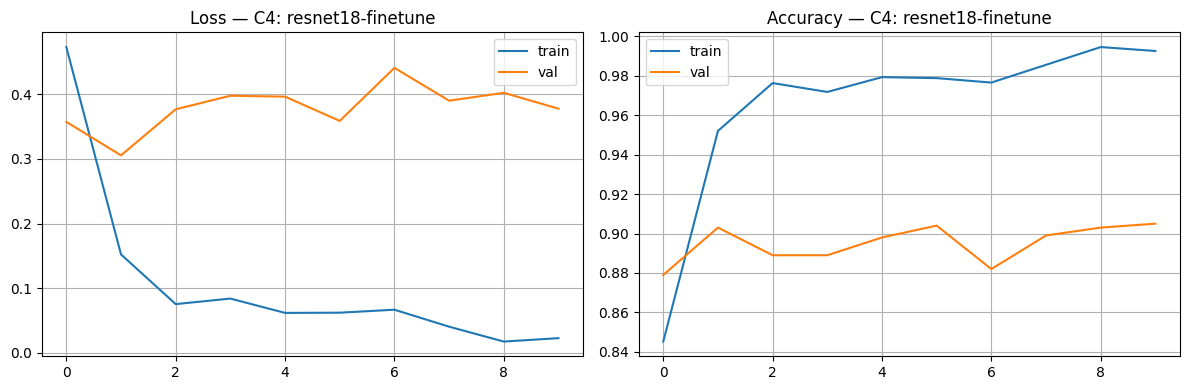

Logged: C4


In [14]:
# C4: resnet18-finetune — ResNet18 с pretrained weights;
# частичное fine-tune: layer4 + fc

model_c4 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in model_c4.parameters():
    p.requires_grad = False
for p in model_c4.layer4.parameters():
    p.requires_grad = True
model_c4.fc = nn.Linear(model_c4.fc.in_features, 10)
model_c4 = model_c4.to(DEVICE)

optimizer_c4 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_c4.parameters()), lr=1e-3)

history_c4 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(1, 11):
    tr_loss, tr_acc = train_one_epoch(model_c4, train_loader_rn, criterion, optimizer_c4, DEVICE)
    vl_loss, vl_acc = evaluate(model_c4, val_loader_rn, criterion, DEVICE)
    history_c4['train_loss'].append(tr_loss); history_c4['val_loss'].append(vl_loss)
    history_c4['train_acc'].append(tr_acc);  history_c4['val_acc'].append(vl_acc)
    print(f'[C4] Epoch {epoch:>2}/10 | loss {tr_loss:.4f}/{vl_loss:.4f} | acc {tr_acc:.3f}/{vl_acc:.3f}')

plot_history(history_c4, title='C4: resnet18-finetune',
             save_path=f'{FIGURES_DIR}/curves_C4.png')
log_run('C4', 'classification', 'STL10',
        'ResNet18-finetune-layer4+fc', 'Adam', 1e-3, 10,
        best_val_accuracy=round(max(history_c4['val_acc']), 4),
        notes='pretrained ResNet18, layer4+fc unfrozen')

In [15]:
# Выбор лучшей модели части A по best_val_accuracy
# test-часть используется один раз — только для финальной оценки лучшей модели

model_registry = {
    'C1': (model_c1, test_loader,    history_c1, 'SimpleCNN-3conv',            'no augmentations'),
    'C2': (model_c2, test_loader,    history_c2, 'SimpleCNN-3conv',            'with augmentations'),
    'C3': (model_c3, test_loader_rn, history_c3, 'ResNet18-head-only',         'backbone frozen'),
    'C4': (model_c4, test_loader_rn, history_c4, 'ResNet18-finetune-layer4+fc','layer4+fc unfrozen'),
}

best_name, best_val_acc = max(
    [(name, max(info[2]['val_acc'])) for name, info in model_registry.items()],
    key=lambda x: x[1]
)
best_model, best_test_loader, best_history, best_summary, best_notes = model_registry[best_name]

print(f'Лучшая модель: {best_name} | val_acc = {best_val_acc:.4f}')

# Финальная оценка на test — один раз
test_loss, test_acc = evaluate(best_model, best_test_loader, criterion, DEVICE)
print(f'Test accuracy ({best_name}): {test_acc:.4f}')

log_run(best_name + '-test', 'classification', 'STL10',
        best_summary, 'Adam', 1e-3, 10,
        best_val_accuracy=round(best_val_acc, 4),
        test_accuracy=round(test_acc, 4),
        notes=best_notes + ' | FINAL TEST')

# Сохраняем best_classifier.pt
torch.save(best_model.state_dict(), f'{ARTIFACTS_DIR}/best_classifier.pt')

# Сохраняем best_classifier_config.json
config = {
    'experiment_id':    best_name,
    'dataset':          'STL10',
    'architecture':     best_summary,
    'img_size':         224 if best_name in ('C3', 'C4') else IMG_SIZE,
    'transform':        'transform_resnet' if best_name in ('C3', 'C4') else 'transform_base',
    'optimizer':        'Adam',
    'lr':               1e-3,
    'epochs':           10,
    'seed':             SEED,
    'best_val_accuracy': round(best_val_acc, 4),
    'test_accuracy':    round(test_acc, 4),
    'notes':            best_notes
}
with open(f'{ARTIFACTS_DIR}/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=4)

Лучшая модель: C3 | val_acc = 0.9410
Test accuracy (C3): 0.9417
Logged: C3-test


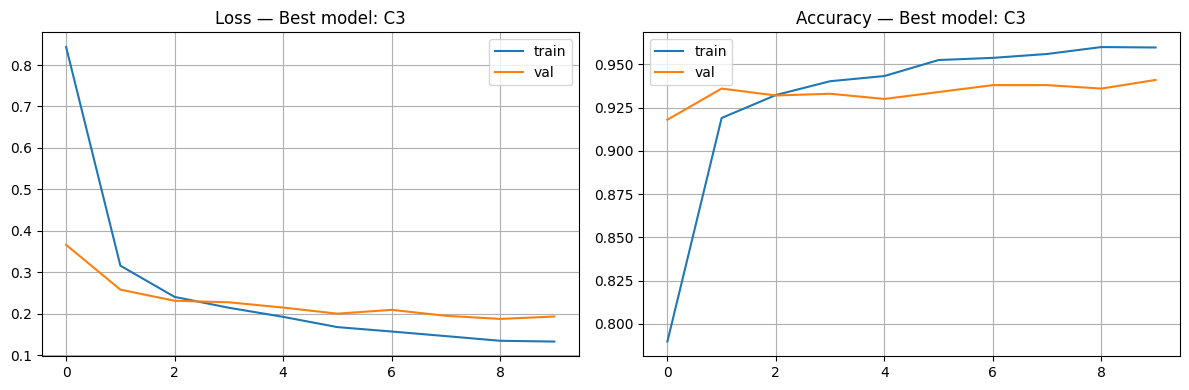

Сохранено: artifacts/figures/classification_curves_best.png


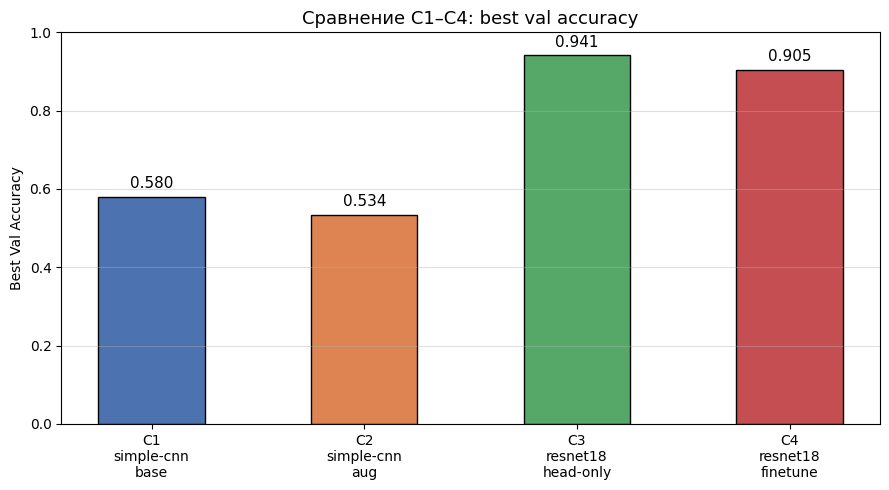

In [16]:
# classification_curves_best.png — график кривых лучшей модели
plot_history(best_history, title=f'Best model: {best_name}',
             save_path=f'{FIGURES_DIR}/classification_curves_best.png')
print('Сохранено: artifacts/figures/classification_curves_best.png')

# classification_compare.png — сравнение C1–C4 (bar plot по best_val_accuracy)
names    = ['C1\nsimple-cnn\nbase', 'C2\nsimple-cnn\naug',
            'C3\nresnet18\nhead-only', 'C4\nresnet18\nfinetune']
val_accs = [max(history_c1['val_acc']), max(history_c2['val_acc']),
            max(history_c3['val_acc']), max(history_c4['val_acc'])]
colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, val_accs, color=colors, width=0.5, edgecolor='black')
ax.bar_label(bars, labels=[f'{v:.3f}' for v in val_accs], padding=4, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Best Val Accuracy')
ax.set_title('Сравнение C1–C4: best val accuracy', fontsize=13)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/classification_compare.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.2. Часть B (S11): сегментация — Segmentation track

Используется готовая pretrained segmentation-модель `DeepLabV3_ResNet50` из `torchvision`.

Проводятся 2 режима оценки:
- **V1**: базовая постобработка маски — argmax по классам + выбор foreground-классов 8 (cat) и 12 (dog).
- **V2**: альтернативная постобработка — морфологическая очистка: удаление компонент связности меньше 500 пикселей.

**Foreground**: классы 8 (cat) и 12 (dog) из COCO-разметки модели — соответствуют животным из OxfordIIITPet.  
Ground truth маски OxfordIIITPet: 1 = foreground (животное), 2 = background, 3 = border.

Метрики: `mean_iou`, `pixel_precision`, `pixel_recall`.

In [17]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from scipy import ndimage

# Загрузка pretrained модели
model_seg = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
model_seg = model_seg.to(DEVICE)
model_seg.eval()

FOREGROUND_CLASSES = [8, 12]

# V1: базовая постобработка маски
def postprocess_v1(logits):
    pred = logits.argmax(0)
    mask = torch.zeros_like(pred)
    for c in FOREGROUND_CLASSES:
        mask |= (pred == c)
    return mask.cpu()

# V2: альтернативная постобработка — морфологическая очистка (удаление мелких компонент)
def postprocess_v2(logits, min_size=500):
    mask = postprocess_v1(logits).numpy()
    labeled, num = ndimage.label(mask)
    for i in range(1, num + 1):
        if (labeled == i).sum() < min_size:
            mask[labeled == i] = 0
    return torch.from_numpy(mask)

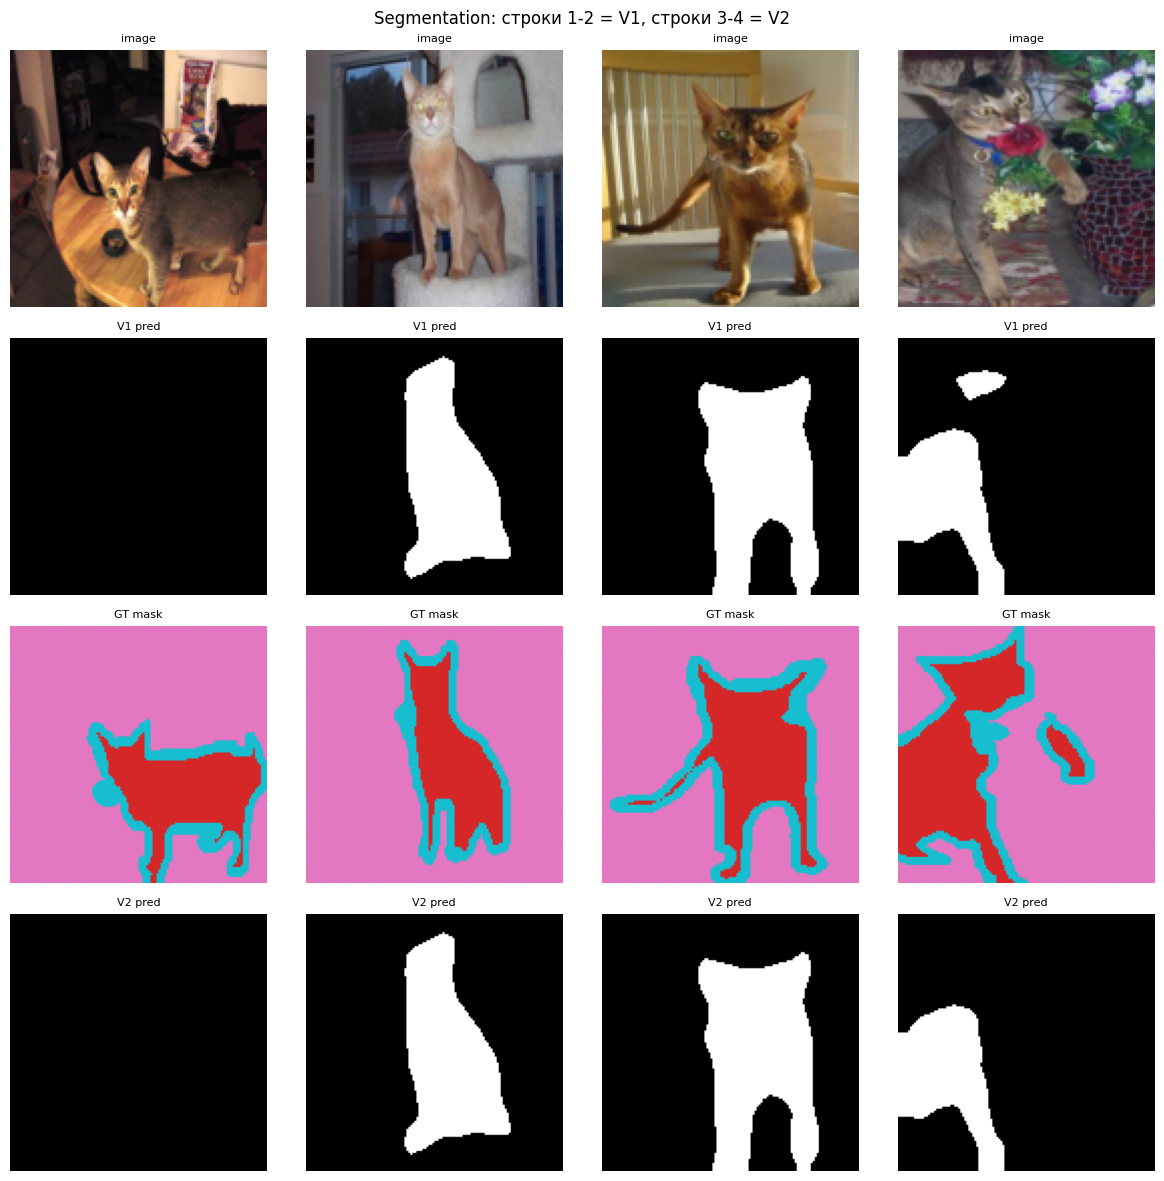

In [18]:
# Визуализация предсказаний модели на нескольких примерах: V1 и V2 в одном файле
# segmentation_examples.png

n_vis = 4
fig, axes = plt.subplots(4, n_vis, figsize=(n_vis * 3, 12))
fig.suptitle('Segmentation: строки 1-2 = V1, строки 3-4 = V2', fontsize=12)

for col in range(n_vis):
    img, mask = test_ds_B[col]
    logits  = predict_mask(model_seg, img, DEVICE)
    pred_v1 = postprocess_v1(logits)
    pred_v2 = postprocess_v2(logits)

    img_np  = denormalize(img, MEAN_A, STD_A).permute(1, 2, 0).numpy()
    mask_np = mask.squeeze().numpy()

    # V1: image | GT
    axes[0, col].imshow(img_np)
    axes[0, col].axis('off')
    axes[0, col].set_title('image', fontsize=8)

    axes[1, col].imshow(pred_v1.numpy(), cmap='gray')
    axes[1, col].axis('off')
    axes[1, col].set_title('V1 pred', fontsize=8)

    # V2: image | pred
    axes[2, col].imshow(mask_np, cmap='tab10', vmin=0, vmax=3)
    axes[2, col].axis('off')
    axes[2, col].set_title('GT mask', fontsize=8)

    axes[3, col].imshow(pred_v2.numpy(), cmap='gray')
    axes[3, col].axis('off')
    axes[3, col].set_title('V2 pred', fontsize=8)

for ax, t in zip(axes[:, 0], ['V1: image', 'V1: pred', 'V2: GT', 'V2: pred']):
    ax.set_ylabel(t, fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/segmentation_examples.png', dpi=120, bbox_inches='tight')
plt.show()

In [19]:
# V1: базовая постобработка — расчёт метрик
print('=== V1: базовая постобработка ===')
iou_v1, prec_v1, rec_v1 = evaluate_seg(model_seg, test_loader_B, postprocess_v1, DEVICE)

log_run('V1', 'segmentation', 'OxfordIIITPet',
        'DeepLabV3_ResNet50 (pretrained)', '—', '—', '—',
        precision=round(prec_v1, 4),
        recall=round(rec_v1, 4),
        mean_iou=round(iou_v1, 4),
        notes='argmax + foreground classes 8 (cat), 12 (dog)')

=== V1: базовая постобработка ===
mean_iou        : 0.6472
pixel_precision : 0.7007
pixel_recall    : 0.8222
Logged: V1


In [20]:
# V2: альтернативная постобработка (морфологическая очистка, min_size=500) — расчёт метрик
print('=== V2: морфологическая очистка (min_size=500) ===')
iou_v2, prec_v2, rec_v2 = evaluate_seg(model_seg, test_loader_B, postprocess_v2, DEVICE)

log_run('V2', 'segmentation', 'OxfordIIITPet',
        'DeepLabV3_ResNet50 (pretrained)', '—', '—', '—',
        precision=round(prec_v2, 4),
        recall=round(rec_v2, 4),
        mean_iou=round(iou_v2, 4),
        notes='argmax + foreground + remove connected components < 500px')

=== V2: морфологическая очистка (min_size=500) ===
mean_iou        : 0.6453
pixel_precision : 0.6826
pixel_recall    : 0.8196
Logged: V2


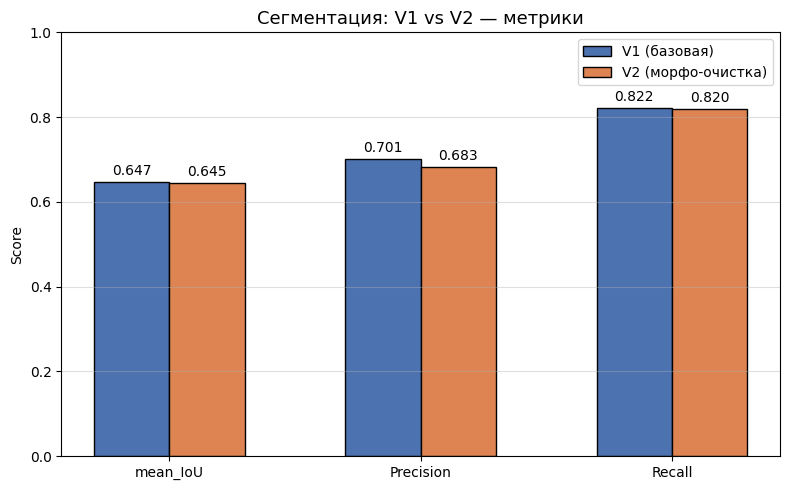

Сохранено: artifacts/figures/segmentation_metrics.png

                          IoU    Precision     Recall
V1 (базовая)           0.6472       0.7007     0.8222
V2 (морфо)             0.6453       0.6826     0.8196


In [21]:
# segmentation_metrics.png — сравнительный график метрик V1 vs V2
metrics_names = ['mean_IoU', 'Precision', 'Recall']
v1_vals = [iou_v1, prec_v1, rec_v1]
v2_vals = [iou_v2, prec_v2, rec_v2]

x     = np.arange(len(metrics_names))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, v1_vals, width, label='V1 (базовая)',       color='#4C72B0', edgecolor='black')
bars2 = ax.bar(x + width/2, v2_vals, width, label='V2 (морфо-очистка)', color='#DD8452', edgecolor='black')
ax.bar_label(bars1, labels=[f'{v:.3f}' for v in v1_vals], padding=3, fontsize=10)
ax.bar_label(bars2, labels=[f'{v:.3f}' for v in v2_vals], padding=3, fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Сегментация: V1 vs V2 — метрики', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/segmentation_metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print('Сохранено: artifacts/figures/segmentation_metrics.png')

# Итоговая таблица
print(f"\n{'':20} {'IoU':>8} {'Precision':>12} {'Recall':>10}")
print(f"{'V1 (базовая)':20} {iou_v1:>8.4f} {prec_v1:>12.4f} {rec_v1:>10.4f}")
print(f"{'V2 (морфо)':20} {iou_v2:>8.4f} {prec_v2:>12.4f} {rec_v2:>10.4f}")